# Replication: Jiang et al. (2024) — Table 1, Table A1, Figure A1

This notebook replicates the main quantitative results from:
> Jiang, E., Matvos, G., Piskorski, T., Seru, A. (2024). "Monetary Tightening
> and U.S. Bank Fragility in 2023: Mark-to-Market Losses and Uninsured Depositor
> Runs?" *Journal of Finance*.

**Methodology (Section II)**:
1. Take Q1 2022 balance sheet snapshot from WRDS Call Reports
2. Apply Q1 2022 → Q1 2023 ETF price changes to each bank's maturity-bucketed holdings
3. RMBS and first-lien mortgages use an RMBS multiplier = ΔMBS ETF / ΔTreasury Index
4. Treasury/other securities and other loans use direct Treasury ETF price changes
5. Aggregate by bank size category (Small, Large non-GSIB, GSIB)

In [1]:
import sys
sys.path.insert(0, "./src/")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from settings import config

DATA_DIR = Path(config("DATA_DIR"))
OUTPUT_DIR = Path(config("OUTPUT_DIR"))
REPORT_DATE = config("REPORT_DATE")
MTM_END_DATE = config("MTM_END_DATE")

## Load Pre-Computed Results

`run_analysis.py` (or `doit`) computes all per-bank MTM losses and saves them
to `_data/`. We load those results here for analysis and presentation.

In [2]:
bank_losses = pd.read_parquet(DATA_DIR / "bank_losses.parquet")
uninsured_ratio = pd.read_parquet(DATA_DIR / "uninsured_ratio.parquet")
insured_coverage = pd.read_parquet(DATA_DIR / "insured_coverage.parquet")
table1 = pd.read_parquet(DATA_DIR / "table1.parquet")
table_a1_a = pd.read_parquet(DATA_DIR / "table_a1_panel_a.parquet")
table_a1_b = pd.read_parquet(DATA_DIR / "table_a1_panel_b.parquet")

print(f"Banks in sample: {len(bank_losses):,}")
print(f"Total MTM loss: ${-bank_losses['total_loss'].sum()/1e9:.1f}B")

Banks in sample: 4,845
Total MTM loss: $1.4B


## Table 1 Replication

**Paper targets** (Jiang et al. Table 1):
| Statistic | All Banks | Small | Large non-GSIB | GSIB |
|-----------|-----------|-------|----------------|------|
| Aggregate Loss | $2.2T | $146B | $623.2B | $1.4T |
| Median Loss/Assets | 9.2% | ... | ... | ... |
| Banks | 4,844 | ~4,000 | ~730 | 17 |

In [3]:
print("=" * 60)
print("TABLE 1: MTM Loss Summary by Bank Size Category")
print("=" * 60)
print(table1.to_string())

TABLE 1: MTM Loss Summary by Bank Size Category
                                All Banks   Small  Large non-GSIB   GSIB
Aggregate Loss                     1419.5   117.9           707.5  594.1
Bank Level Loss                      23.5    18.2           239.6  949.4
Bank Level Loss Std                   4.6     0.0             3.2   63.1
Share RMBS                            6.5     5.6            11.8    0.0
Share RMBS Std                       15.5    14.7            18.5   27.5
Share Treasury and Other             18.4    19.4            13.2   27.9
Share Treasury and Other Std         21.1    21.5            17.1   37.2
Share Residential Mortgage           17.1    16.7            18.6   34.7
Share Residential Mortgage Std       20.4    20.4            19.7   42.6
Share Other Loan                     40.0    39.6            42.2    0.0
Share Other Loan Std                 23.0    22.8            23.6    0.0
Loss/Asset                            7.4     7.4             7.3    1.8
Los

In [4]:
# Compare to paper targets
paper_targets = {
    "All Banks": {"agg_loss_B": 2200, "n_banks": 4844},
    "Small": {"agg_loss_B": 146, "n_banks": 4095},
    "Large non-GSIB": {"agg_loss_B": 623, "n_banks": 732},
    "GSIB": {"agg_loss_B": 1400, "n_banks": 17},
}

print("\nComparison to paper targets:")
for group, targets in paper_targets.items():
    if group in table1.columns:
        our_loss = table1.loc["Aggregate Loss", group]
        our_n = table1.loc["Number of Banks", group]
        print(f"  {group}:")
        print(f"    Aggregate Loss: ${our_loss:.0f}B (paper: ${targets['agg_loss_B']}B)")
        print(f"    Banks: {our_n} (paper: {targets['n_banks']})")


Comparison to paper targets:
  All Banks:
    Aggregate Loss: $1420B (paper: $2200B)
    Banks: 4845.0 (paper: 4844)
  Small:
    Aggregate Loss: $118B (paper: $146B)
    Banks: 4089.0 (paper: 4095)
  Large non-GSIB:
    Aggregate Loss: $708B (paper: $623B)
    Banks: 736.0 (paper: 732)
  GSIB:
    Aggregate Loss: $594B (paper: $1400B)
    Banks: 20.0 (paper: 17)


## Distribution of Loss/Asset Ratio

The loss-to-assets ratio characterizes how much each bank's asset value
would have declined if it marked all holdings to market as of Q1 2023.

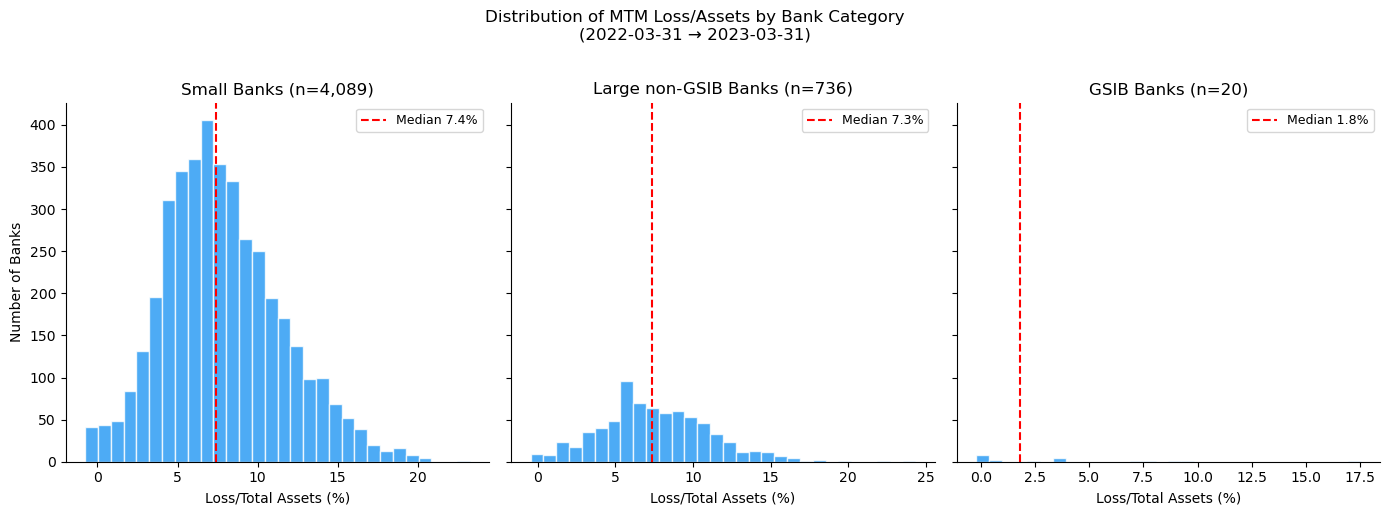

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

for ax, category in zip(axes, ["Small", "Large non-GSIB", "GSIB"]):
    mask = bank_losses["size_category"] == category
    subset = bank_losses.loc[mask, "loss_over_assets"].dropna() * 100
    ax.hist(subset, bins=30, color="#2196F3", edgecolor="white", alpha=0.8)
    ax.axvline(subset.median(), color="red", linestyle="--", linewidth=1.5,
               label=f"Median {subset.median():.1f}%")
    ax.set_xlabel("Loss/Total Assets (%)")
    ax.set_title(f"{category} Banks (n={mask.sum():,})")
    ax.legend(fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Number of Banks")
plt.suptitle(f"Distribution of MTM Loss/Assets by Bank Category\n({REPORT_DATE} → {MTM_END_DATE})", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Table A1: Balance Sheet Composition

In [6]:
print("=" * 60)
print("TABLE A1: Balance Sheet Composition (Q1 2022, $billions)")
print("=" * 60)

print("-" * 60)
print("Panel A: Bank Asset Composition, Q1 2022")
print("-" * 60)
print(table_a1_a.to_string())

print("-" * 60)
print("Panel B: Bank Liability Composition, Q1 2022")
print("-" * 60)
print(table_a1_b.to_string())

TABLE A1: Balance Sheet Composition (Q1 2022, $billions)
------------------------------------------------------------
Panel A: Bank Asset Composition, Q1 2022
------------------------------------------------------------
                                 Aggregate  Full sample(mean)  Full sample(sd)  small(mean)  small(sd)  large(mean)   large(sd)   GSIB(mean)      GSIB(sd)
Total Asset $                 2.398913e+10           864185.5        1410910.0     345499.2   287494.6    9453305.2  15362366.8  671360583.0  1.087273e+09
Number of Banks               4.841000e+03             4841.0              NaN       4089.0        NaN        736.0         NaN         16.0           NaN
Cash                          1.410000e+01               13.1              9.8         13.7       10.1          9.8         7.2         41.3  2.780000e+01
Security                      2.550000e+01               23.6             15.5         24.1       16.0         21.0        12.1         12.9  1.510000e+01
Treas

## Figure A1: Aggregate Bank Balance Sheet

Stacked bar chart comparing book-value assets, MTM assets, and liabilities.

/Users/joewang/Desktop/MSFM_Courses/FINM32900/final_project/p08_jiang_et_al_2024/src/create_figure_a1.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: /Users/joewang/Desktop/MSFM_Courses/FINM32900/final_project/p08_jiang_et_al_2024/_output/figure_a1.pdf
Saved: /Users/joewang/Desktop/MSFM_Courses/FINM32900/final_project/p08_jiang_et_al_2024/_output/figure_a1.png


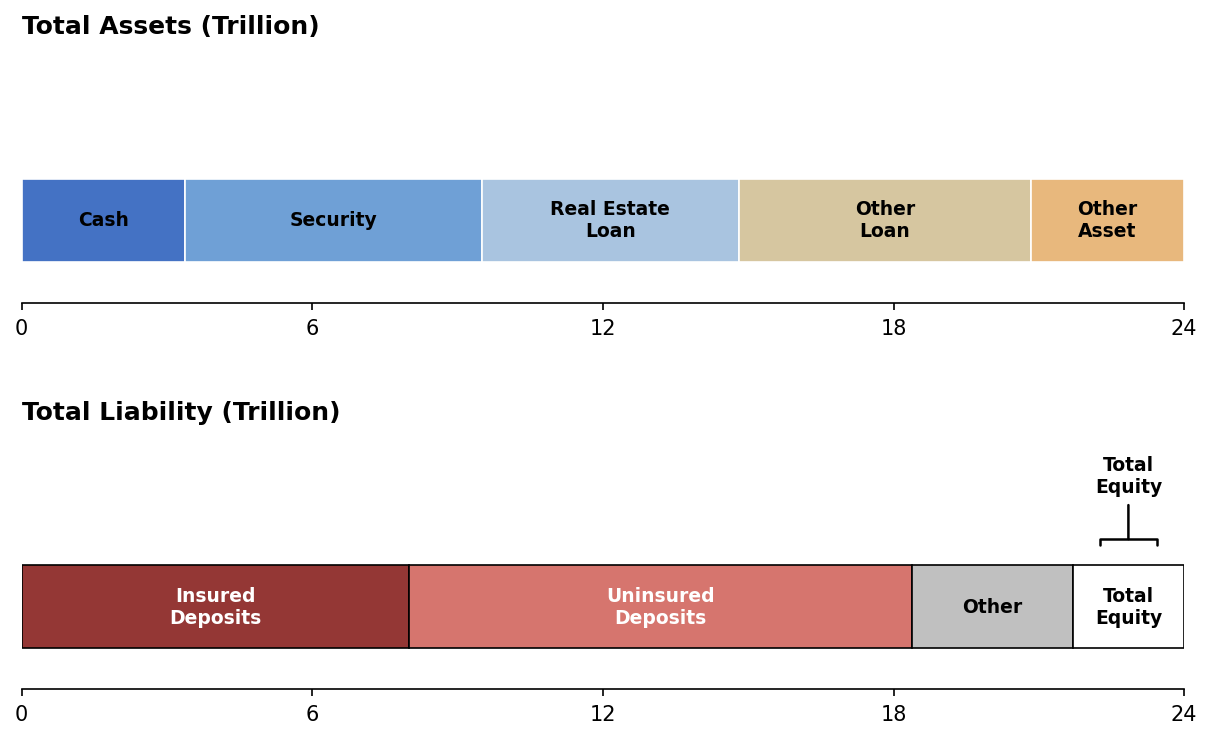

In [7]:
from create_figure_a1 import create_figure_a1
create_figure_a1()

# Display saved figure
from IPython.display import Image
Image(str(OUTPUT_DIR / "figure_a1.png"))

## Updated Replication with Most Recent Data

Below we recompute the analysis using the full date range from the `.env`
configuration (END_DATE in settings), allowing the user to see how the
MTM losses would look with the most recently available ETF prices.

In [8]:
import pull_wrds
import pull_etf_data
import clean_data
import calc_mtm_losses
import calc_table1

# Reload ETF data with full date range
etf_raw = pull_etf_data.load_etf_data()

# Get the most recent available quarter-end date
etf_quarters = etf_raw.resample("QE").first()
latest_date = str(etf_quarters.index[-1].date())
print(f"Most recent ETF quarter-end: {latest_date}")

Most recent ETF quarter-end: 2023-09-30


In [9]:
# Recompute with updated end date
rcon1 = pull_wrds.load_rcon_series_1()
rcon2 = pull_wrds.load_rcon_series_2()
rcfd1 = pull_wrds.load_rcfd_series_1()
rcfd2 = pull_wrds.load_rcfd_series_2()

rmbs = clean_data.get_rmbs(rcfd1, rcon1, rcon2, REPORT_DATE)
treasuries = clean_data.get_treasuries(rcfd2, rcon2, REPORT_DATE)
loans = clean_data.get_loans(rcon1, REPORT_DATE)
other_loans = clean_data.get_other_loans(rcon2, rcfd1, REPORT_DATE)
total_assets_updated = clean_data.get_total_assets(rcfd2, rcon2, REPORT_DATE)
total_assets_updated = calc_mtm_losses.classify_banks(total_assets_updated)
uninsured = clean_data.get_uninsured_deposits(rcon1, REPORT_DATE)
insured = clean_data.get_insured_deposits(rcon1, REPORT_DATE)

etf_q_updated = clean_data.clean_etf_prices(etf_raw, REPORT_DATE, latest_date)
price_changes_updated = calc_mtm_losses.calc_price_changes(etf_q_updated, REPORT_DATE, latest_date)
rmbs_mult_updated = calc_mtm_losses.calc_rmbs_multiplier(etf_q_updated, REPORT_DATE, latest_date)

bank_losses_updated = calc_mtm_losses.calc_bank_losses(
    rmbs, loans, treasuries, other_loans, total_assets_updated,
    price_changes_updated, rmbs_mult_updated,
)
uninsured_ratio_updated = calc_mtm_losses.calc_uninsured_deposit_ratio(uninsured, bank_losses_updated)
insured_cov_updated = calc_mtm_losses.calc_insured_deposit_coverage(insured, uninsured, bank_losses_updated)

table1_updated = calc_table1.calc_table1(bank_losses_updated, uninsured_ratio_updated, insured_cov_updated)

print(f"\nUpdated Table 1 ({REPORT_DATE} → {latest_date}):")
print(table1_updated.to_string())


Updated Table 1 (2022-03-31 → 2023-09-30):
                                All Banks   Small  Large non-GSIB   GSIB
Aggregate Loss                     1284.1   104.9           632.3  546.9
Bank Level Loss                      20.4    15.9           212.6  874.1
Bank Level Loss Std                   4.2     0.0             3.0   58.6
Share RMBS                            7.0     5.9            12.6    0.0
Share RMBS Std                       16.2    15.4            18.9   28.5
Share Treasury and Other             19.2    20.5            13.9   26.2
Share Treasury and Other Std         21.9    22.4            17.7   37.2
Share Residential Mortgage           17.7    17.1            19.9   34.9
Share Residential Mortgage Std       21.1    21.0            20.4   42.6
Share Other Loan                     37.1    36.8            39.3    0.0
Share Other Loan Std                 23.1    23.0            23.5    0.0
Loss/Asset                            6.5     6.5             6.4    1.6
Loss/As